In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [15]:
# UK Budget Impact Model

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Model assumptions

eligible_population = 3290941

annual_cost_per_patient = 2500

uptake = {
    "Year 1": 0.05,
    "Year 2": 0.10,
    "Year 3": 0.15,
    "Year 4": 0.20,
    "Year 5": 0.25
}


results = []

for year, rate in uptake.items():
    
    treated_patients = eligible_population * rate
    
    budget_impact = treated_patients * annual_cost_per_patient
    
    results.append({
        "Year": year,
        "Uptake": rate,
        "Patients treated": round(treated_patients),
        "Annual cost (£)": round(budget_impact)
    })


uk_budget_impact = pd.DataFrame(results)

uk_budget_impact

,Year,Uptake,Patients treated,Annual cost (£)
0,Year 1,0.05,164547,411367625
1,Year 2,0.10,329094,822735250
2,Year 3,0.15,493641,1234102875
3,Year 4,0.20,658188,1645470500
4,Year 5,0.25,822735,2056838125


In [17]:
from pathlib import Path

# Create the folder if it doesn't already exist
output_dir = Path("../data/uk/budget_impact")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the DataFrame
uk_budget_impact.to_csv(output_dir / "uk_budget_impact.csv", index=False)

print("Saved to:", output_dir / "uk_budget_impact.csv")

Saved to: ..\data\uk\budget_impact\uk_budget_impact.csv


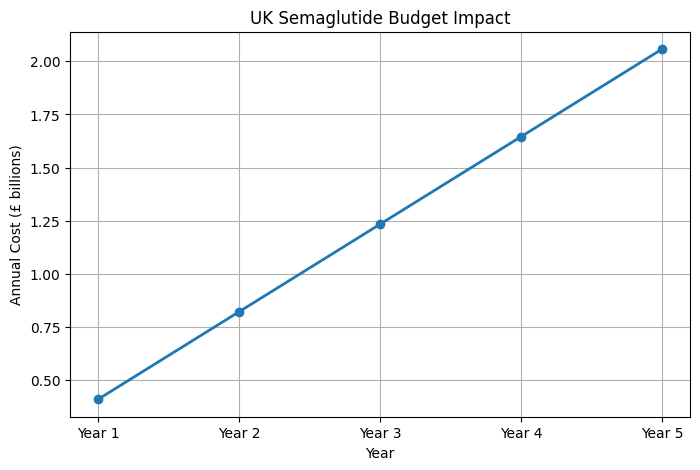

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    uk_budget_impact["Year"],
    uk_budget_impact["Annual cost (£)"] / 1e9,
    marker="o",
    linewidth=2
)

plt.title("UK Semaglutide Budget Impact")
plt.xlabel("Year")
plt.ylabel("Annual Cost (£ billions)")
plt.grid(True)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '..\\reports\\uk\\figures\\uk_budget_impact.png'

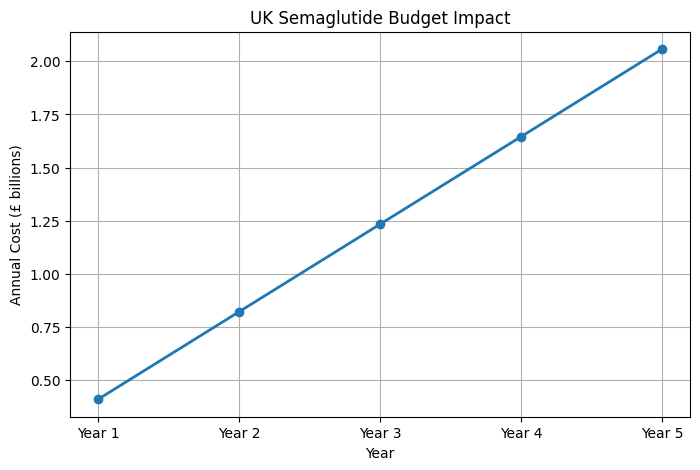

In [21]:
from pathlib import Path

output_fig = Path("../reports/uk/figures")

plt.figure(figsize=(8,5))

plt.plot(
    uk_budget_impact["Year"],
    uk_budget_impact["Annual cost (£)"] / 1e9,
    marker="o",
    linewidth=2
)

plt.title("UK Semaglutide Budget Impact")
plt.xlabel("Year")
plt.ylabel("Annual Cost (£ billions)")
plt.grid(True)

plt.savefig(output_fig / "uk_budget_impact.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved.")

In [20]:
from pathlib import Path

output_fig = Path("../reports/uk/figures")

print(output_fig.exists())
print(output_fig.is_dir())
print(output_fig.is_file())

True
False
True


In [22]:
from pathlib import Path

reports = Path("../reports")

print("Reports exists:", reports.exists())

print("\nContents of reports:")
for item in reports.iterdir():
    print("-", item.name, "(Folder)" if item.is_dir() else "(File)")

Reports exists: True

Contents of reports:
- uk (Folder)
- usa (Folder)


In [23]:
uk_reports = Path("../reports/uk")

print("\nUK folder exists:", uk_reports.exists())

if uk_reports.exists():
    print("\nContents of reports/uk:")
    for item in uk_reports.iterdir():
        print("-", item.name, "(Folder)" if item.is_dir() else "(File)")


UK folder exists: True

Contents of reports/uk:
- figures (File)
- tables (File)
- uk_model_summary.csv (File)


# UK Model Completed